## 1. Setup and load

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

DRIVE = '/content/drive/MyDrive/ekstraklasa-2025-26'
SOFA = f'{DRIVE}/sofascore'
FIG = '/content/figures'
os.makedirs(FIG, exist_ok=True)

JAGA = 'crimson'
LECH = 'royalblue'
LEGIA = 'forestgreen'
GREY = 'lightgrey'

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
players = pd.read_csv(f'{SOFA}/player_master.csv')
player_match = pd.read_csv(f'{SOFA}/sofascore_player_match.csv')
shots = pd.read_csv(f'{SOFA}/sofascore_shots.csv')

def role(pos):
    if pos is None or (isinstance(pos, float) and np.isnan(pos)):
        return None
    p = str(pos).upper()
    if p.startswith('G'): return 'GK'
    if p.startswith('D'): return 'DEF'
    if p.startswith('M'): return 'MID'
    if p.startswith('F') or p.startswith('S') or p.startswith('A'): return 'FWD'
    return 'MID'

players['role'] = players['canonical_position'].apply(role)

print(players.shape, player_match.shape, shots.shape)
print()
print(players['role'].value_counts(dropna=False))
print()
print(players.head(3))

(625, 57) (13206, 43) (8432, 17)

role
MID    265
DEF    174
FWD    117
GK      69
Name: count, dtype: int64

   player_id               name               team canonical_position  \
0     926007  Filip Majchrowicz     Radomiak Radom                  G   
1    1033201  Xavier Dziekoński  MKS Korona Kielce                  G   
2     316216      Bartosz Nowak       GKS Katowice                  F   

  lineup_position  age         dob  height_cm country  market_value_eur  ...  \
0               G   26  2000-02-09      194.0  Poland          635000.0  ...   
1               G   22  2003-10-06      188.0  Poland         2200000.0  ...   
2               F   32  1993-08-25      180.0  Poland          360000.0  ...   

   goals_p90  xg_p90  xa_p90  shots_p90  key_passes_p90  prog_carries_p90  \
0        NaN     NaN   0.001      0.000           0.029             0.000   
1        NaN     NaN   0.004      0.000           0.029             0.029   
2      0.269   0.221   0.304      2.425      

## 2. Squad demographics

Minutes-weighted average squad age vs share of minutes given to under-21
players. Top-left of the scatter means a young squad, bottom-right means
a veteran one.

In [ ]:
demo = players.dropna(subset=['age', 'minutes']).copy()
demo = demo[demo['minutes'] > 0]

team_age = (demo.groupby('team')
              .apply(lambda d: np.average(d['age'], weights=d['minutes']))
              .reset_index(name='weighted_age'))

demo['is_u21'] = demo['age'] < 21
u21_share = (demo.groupby('team')
               .apply(lambda d: d.loc[d['is_u21'], 'minutes'].sum() / d['minutes'].sum() * 100)
               .reset_index(name='u21_share'))

team_demo = team_age.merge(u21_share, on='team').sort_values('weighted_age')
print(team_demo.to_string(index=False))

                        team  weighted_age  u21_share
            KS Lechia Gdańsk     24.622229   0.503616
           Raków Częstochowa     25.596619   1.029170
                 Lech Poznań     25.646562  13.325927
           MKS Korona Kielce     25.686392   0.863686
                 Widzew Łódź     25.785945   0.303801
       Jagiellonia Białystok     25.811316   9.549783
                    Cracovia     26.250744   1.198977
              Zagłębie Lubin     27.169323  12.060636
                Motor Lublin     27.366576   2.488728
              Pogoń Szczecin     27.463445   5.267361
               Górnik Zabrze     27.475576   0.699553
              Legia Warszawa     27.502992   2.755052
               Piast Gliwice     27.601910   6.550193
              Radomiak Radom     27.863025   0.029667
            MZKS Arka Gdynia     27.969136   2.911122
Bruk-Bet Termalica Nieciecza     28.750274   0.000000
                 Wisła Płock     29.498115   0.748043
                GKS Katowice

/tmp/ipykernel_3644/580409080.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: np.average(d['age'], weights=d['minutes']))
/tmp/ipykernel_3644/580409080.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.loc[d['is_u21'], 'minutes'].sum() / d['minutes'].sum() * 100)


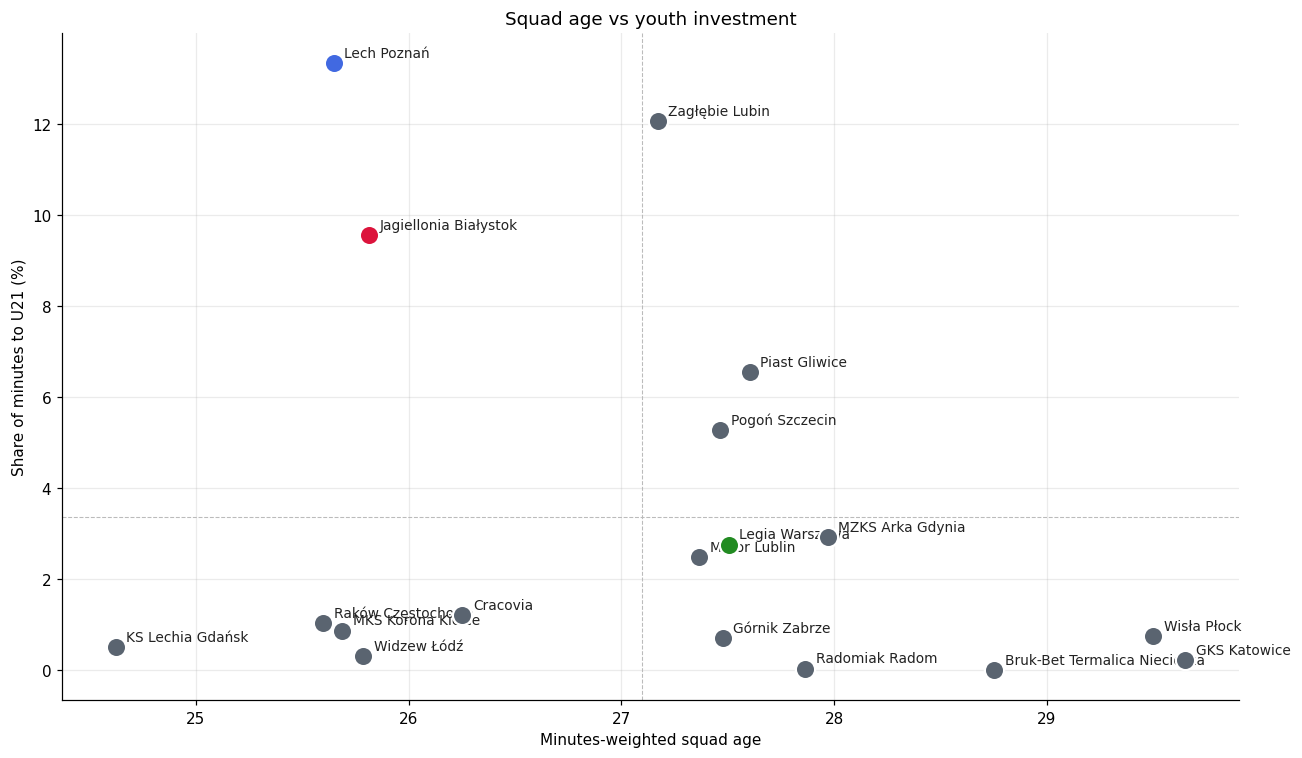

In [ ]:
focus_colors = {
    'Jagiellonia Białystok': JAGA,
    'Lech Poznań': LECH,
    'Legia Warszawa': LEGIA,
}
default_color = '#5a6470'

fig, ax = plt.subplots(figsize=(12, 7))
for _, r in team_demo.iterrows():
    c = focus_colors.get(r['team'], default_color)
    ax.scatter(r['weighted_age'], r['u21_share'], s=160, c=c,
               edgecolor='white', linewidth=1.5, zorder=3)
    ax.annotate(r['team'], (r['weighted_age'], r['u21_share']),
                xytext=(7, 4), textcoords='offset points', fontsize=9, color='#222')

ax.axhline(team_demo['u21_share'].mean(), color='#bbb', lw=0.7, ls='--')
ax.axvline(team_demo['weighted_age'].mean(), color='#bbb', lw=0.7, ls='--')
ax.set_xlabel('Minutes-weighted squad age')
ax.set_ylabel('Share of minutes to U21 (%)')
ax.set_title('Squad age vs youth investment')
plt.tight_layout()
plt.savefig(f'{FIG}/02_demographics.png')
plt.show()

## 3. League top performers

min_minutes = 1000

In [ ]:
MIN_MINUTES = 1000
pool = players[players['minutes'] >= MIN_MINUTES].copy()

ATTACKING_METRICS = {
    'goals_p90':        'G/90',
    'xg_p90':           'xG/90',
    'xa_p90':           'xA/90',
    'shots_p90':        'Sh/90',
    'key_passes_p90':   'KP/90',
    'prog_carries_p90': 'PrgC/90',
}

def attacking_top(n=15):
    sub = pool[pool['role'].isin(['FWD', 'MID'])].copy()
    for m in ATTACKING_METRICS:
        sub[m] = sub[m].fillna(0)
    z_cols = []
    for m in ATTACKING_METRICS:
        sub[f'{m}_z'] = (sub[m] - sub[m].mean()) / sub[m].std()
        z_cols.append(f'{m}_z')
    sub['composite'] = sub[z_cols].mean(axis=1)
    sub = sub.sort_values('composite', ascending=False).head(n)
    out = sub[['name', 'team', 'role', 'age', 'minutes', 'composite']
              + list(ATTACKING_METRICS)].copy()
    out['minutes'] = out['minutes'].astype(int)
    out['composite'] = out['composite'].round(2)
    for m in ATTACKING_METRICS:
        out[m] = out[m].round(2)
    out = out.rename(columns=ATTACKING_METRICS)
    return out.reset_index(drop=True)

def gk_top(n=10):
    sub = pool[pool['role'] == 'GK'].copy()
    sub['gp_p90']    = sub['goalsPrevented'] / sub['minutes'] * 90
    sub['saves_p90'] = sub['saves'] / sub['minutes'] * 90
    z_cols = []
    for m in ['gp_p90', 'saves_p90']:
        sub[f'{m}_z'] = (sub[m] - sub[m].mean()) / sub[m].std()
        z_cols.append(f'{m}_z')
    sub['composite'] = sub[z_cols].mean(axis=1)
    sub = sub.sort_values('composite', ascending=False).head(n)
    out = sub[['name', 'team', 'age', 'minutes', 'composite',
               'goalsPrevented', 'gp_p90', 'saves', 'saves_p90']].copy()
    out['minutes'] = out['minutes'].astype(int)
    for c in ['composite', 'gp_p90', 'saves_p90', 'goalsPrevented']:
        out[c] = out[c].round(2)
    return out.reset_index(drop=True)

print('=== Top 15 attacking players (FWD + MID) ===')
print(attacking_top(15).to_string(index=False))
print()
print('=== Top 10 goalkeepers ===')
print(gk_top(10).to_string(index=False))

=== Top 15 attacking players (FWD + MID) ===
                name                  team role  age  minutes  composite  G/90  xG/90  xA/90  Sh/90  KP/90  PrgC/90
      Ali Gholizadeh           Lech Poznań  MID   30     1137       2.46  0.48   0.40   0.43   2.77   3.40     2.93
          Luis Palma           Lech Poznań  MID   26     1655       1.97  0.54   0.33   0.34   4.30   2.83     1.20
        Tomáš Bobček      KS Lechia Gdańsk  FWD   24     2464       1.45  0.73   0.72   0.09   4.27   1.06     0.58
        Mikael Ishak           Lech Poznań  FWD   33     2436       1.33  0.59   0.61   0.15   4.03   1.26     0.66
        Dawid Błanik     MKS Korona Kielce  FWD   29     1895       1.31  0.43   0.30   0.30   2.28   2.61     1.33
      Kamil Grosicki        Pogoń Szczecin  MID   37     2184       1.28  0.25   0.33   0.32   2.84   2.72     1.07
        Jason Lokilo         Piast Gliwice  MID   27     1020       1.23  0.00   0.10   0.34   1.85   2.91     3.44
      Afimico Pululu Jagiel

## 4. Percentile pizzas - attackers vs league

Per-90 percentile rank against all attacking players (FWD + MID, 900+ min).
Each axis is one metric, height is the player's percentile within that pool.

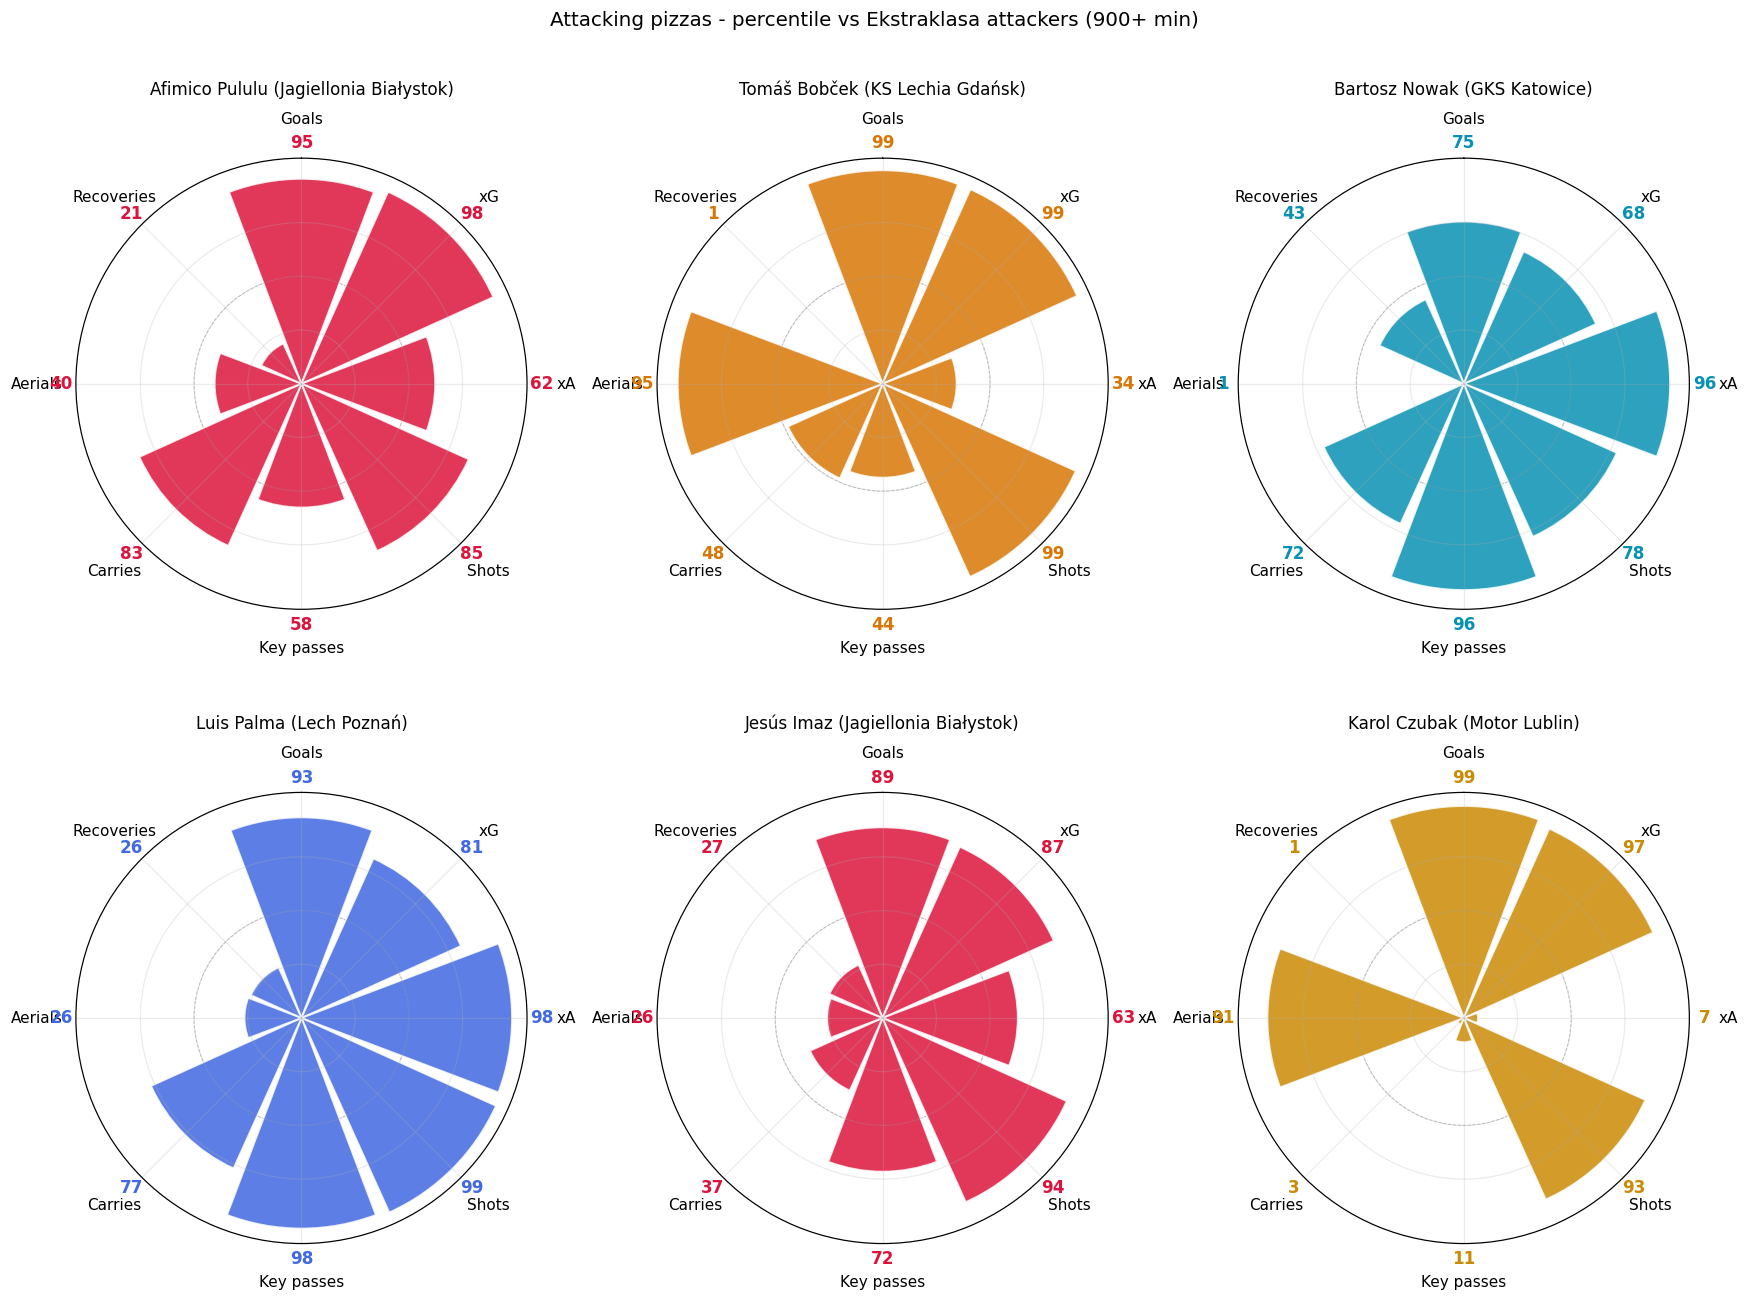

In [ ]:
ATTACK_PIZZA = {
    'Goals':      'goals_p90',
    'xG':         'xg_p90',
    'xA':         'xa_p90',
    'Shots':      'shots_p90',
    'Key passes': 'key_passes_p90',
    'Carries':    'prog_carries_p90',
    'Aerials':    '_aerials_p90',
    'Recoveries': 'recoveries_p90',
}

attack_pool = pool[pool['role'].isin(['FWD', 'MID'])].copy()
attack_pool['_aerials_p90'] = attack_pool['aerialWon'] / attack_pool['minutes'] * 90
for m in ATTACK_PIZZA.values():
    attack_pool[m] = attack_pool[m].fillna(0)

def pizza(ax, player_row, pool_df, metrics, color, title):
    labels = list(metrics.keys())
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    pcts = [(pool_df[c] < player_row[c]).mean() * 100 for c in metrics.values()]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.bar(angles, pcts, width=2 * np.pi / N * 0.92,
           color=color, edgecolor='white', linewidth=1.2, alpha=0.85)
    for ang, p in zip(angles, pcts):
        ax.text(ang, 112, f'{p:.0f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels([])
    ax.set_ylim(0, 105)
    ax.axhline(50, color='#bbb', lw=0.6, ls='--', zorder=0)
    ax.tick_params(axis='x', pad=15)
    ax.set_title(title, y=1.12, fontsize=11)

ATTACKER_PICKS = [
    ('Afimico Pululu', JAGA),
    ('Tomáš Bobček',   '#d97706'),
    ('Bartosz Nowak',  '#0891b2'),
    ('Luis Palma',     LECH),
    ('Jesús Imaz',     JAGA),
    ('Karol Czubak',   '#ca8a04'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
for ax, (name, color) in zip(axes, ATTACKER_PICKS):
    row = attack_pool[attack_pool['name'] == name]
    if row.empty:
        ax.set_visible(False)
        continue
    pizza(ax, row.iloc[0], attack_pool, ATTACK_PIZZA, color, f'{name} ({row.iloc[0]["team"]})')

plt.suptitle('Attacking pizzas - percentile vs Ekstraklasa attackers (900+ min)',
             y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG}/04_pizzas_attackers.png')
plt.show()

## 5. Percentile pizzas - goalkeepers

Per-90 percentile rank against all goalkeepers with 900+ minutes.
Different metric set than attackers - shot-stopping plus distribution.

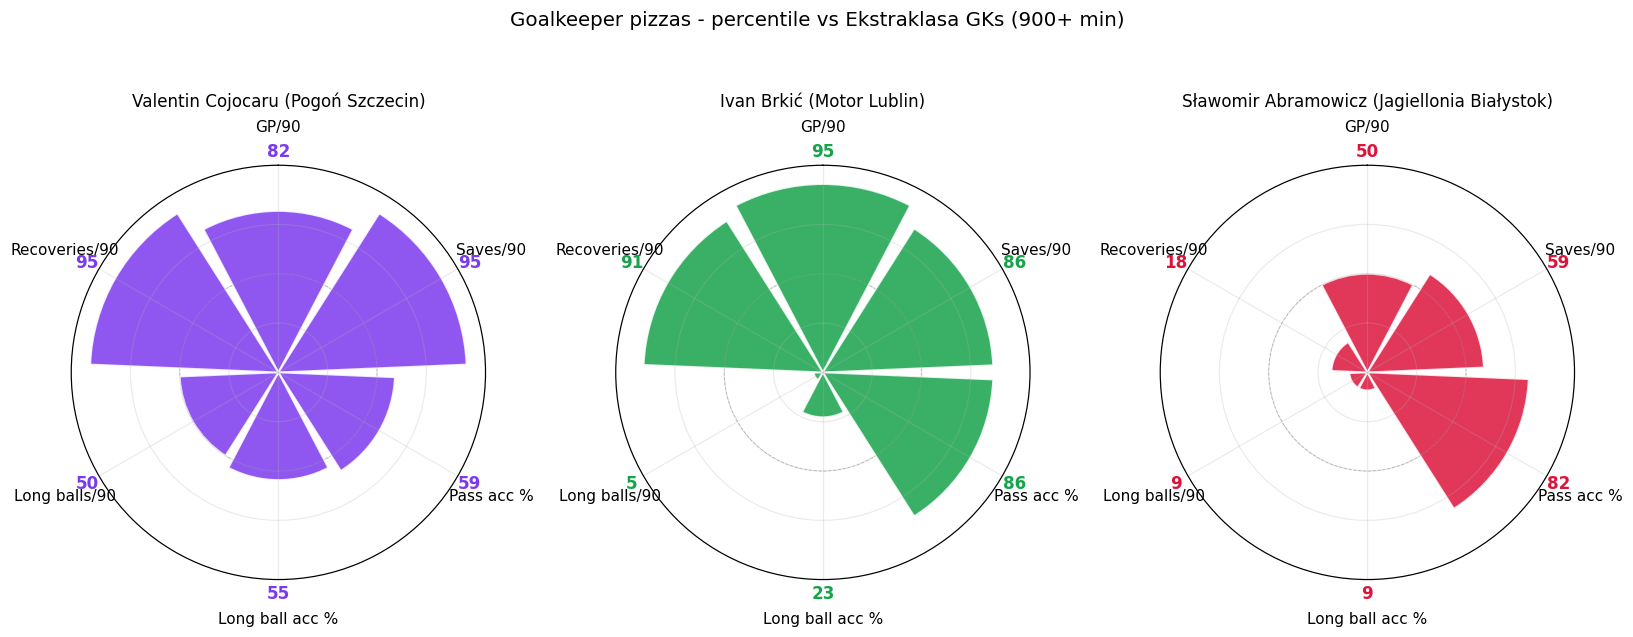

In [ ]:
GK_PIZZA = {
    'GP/90':           '_gp_p90',
    'Saves/90':        '_saves_p90',
    'Pass acc %':      '_pass_acc',
    'Long ball acc %': '_lb_acc',
    'Long balls/90':   '_lb_p90',
    'Recoveries/90':   '_recov_p90',
}

gk_pool = pool[pool['role'] == 'GK'].copy()
gk_pool['_gp_p90']    = gk_pool['goalsPrevented'] / gk_pool['minutes'] * 90
gk_pool['_saves_p90'] = gk_pool['saves'] / gk_pool['minutes'] * 90
gk_pool['_pass_acc']  = gk_pool['accuratePass'] / gk_pool['totalPass'].replace(0, np.nan) * 100
gk_pool['_lb_acc']    = gk_pool['accurateLongBalls'] / gk_pool['totalLongBalls'].replace(0, np.nan) * 100
gk_pool['_lb_p90']    = gk_pool['totalLongBalls'] / gk_pool['minutes'] * 90
gk_pool['_recov_p90'] = gk_pool['ballRecovery'] / gk_pool['minutes'] * 90
for col in GK_PIZZA.values():
    gk_pool[col] = gk_pool[col].fillna(0)

GK_PICKS = [
    ('Valentin Cojocaru',   '#7c3aed'),
    ('Ivan Brkić',          '#16a34a'),
    ('Sławomir Abramowicz', JAGA),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), subplot_kw=dict(polar=True))
for ax, (name, color) in zip(axes, GK_PICKS):
    row = gk_pool[gk_pool['name'] == name]
    if row.empty:
        ax.set_visible(False)
        continue
    pizza(ax, row.iloc[0], gk_pool, GK_PIZZA, color, f'{name} ({row.iloc[0]["team"]})')

plt.suptitle('Goalkeeper pizzas - percentile vs Ekstraklasa GKs (900+ min)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG}/05_pizzas_gks.png')
plt.show()

## 6. Shot maps - selected attackers

Vertical half-pitch, attack going up. Each circle is one shot, size scaled
by xG, filled circles are goals, hollow circles are non-goals.

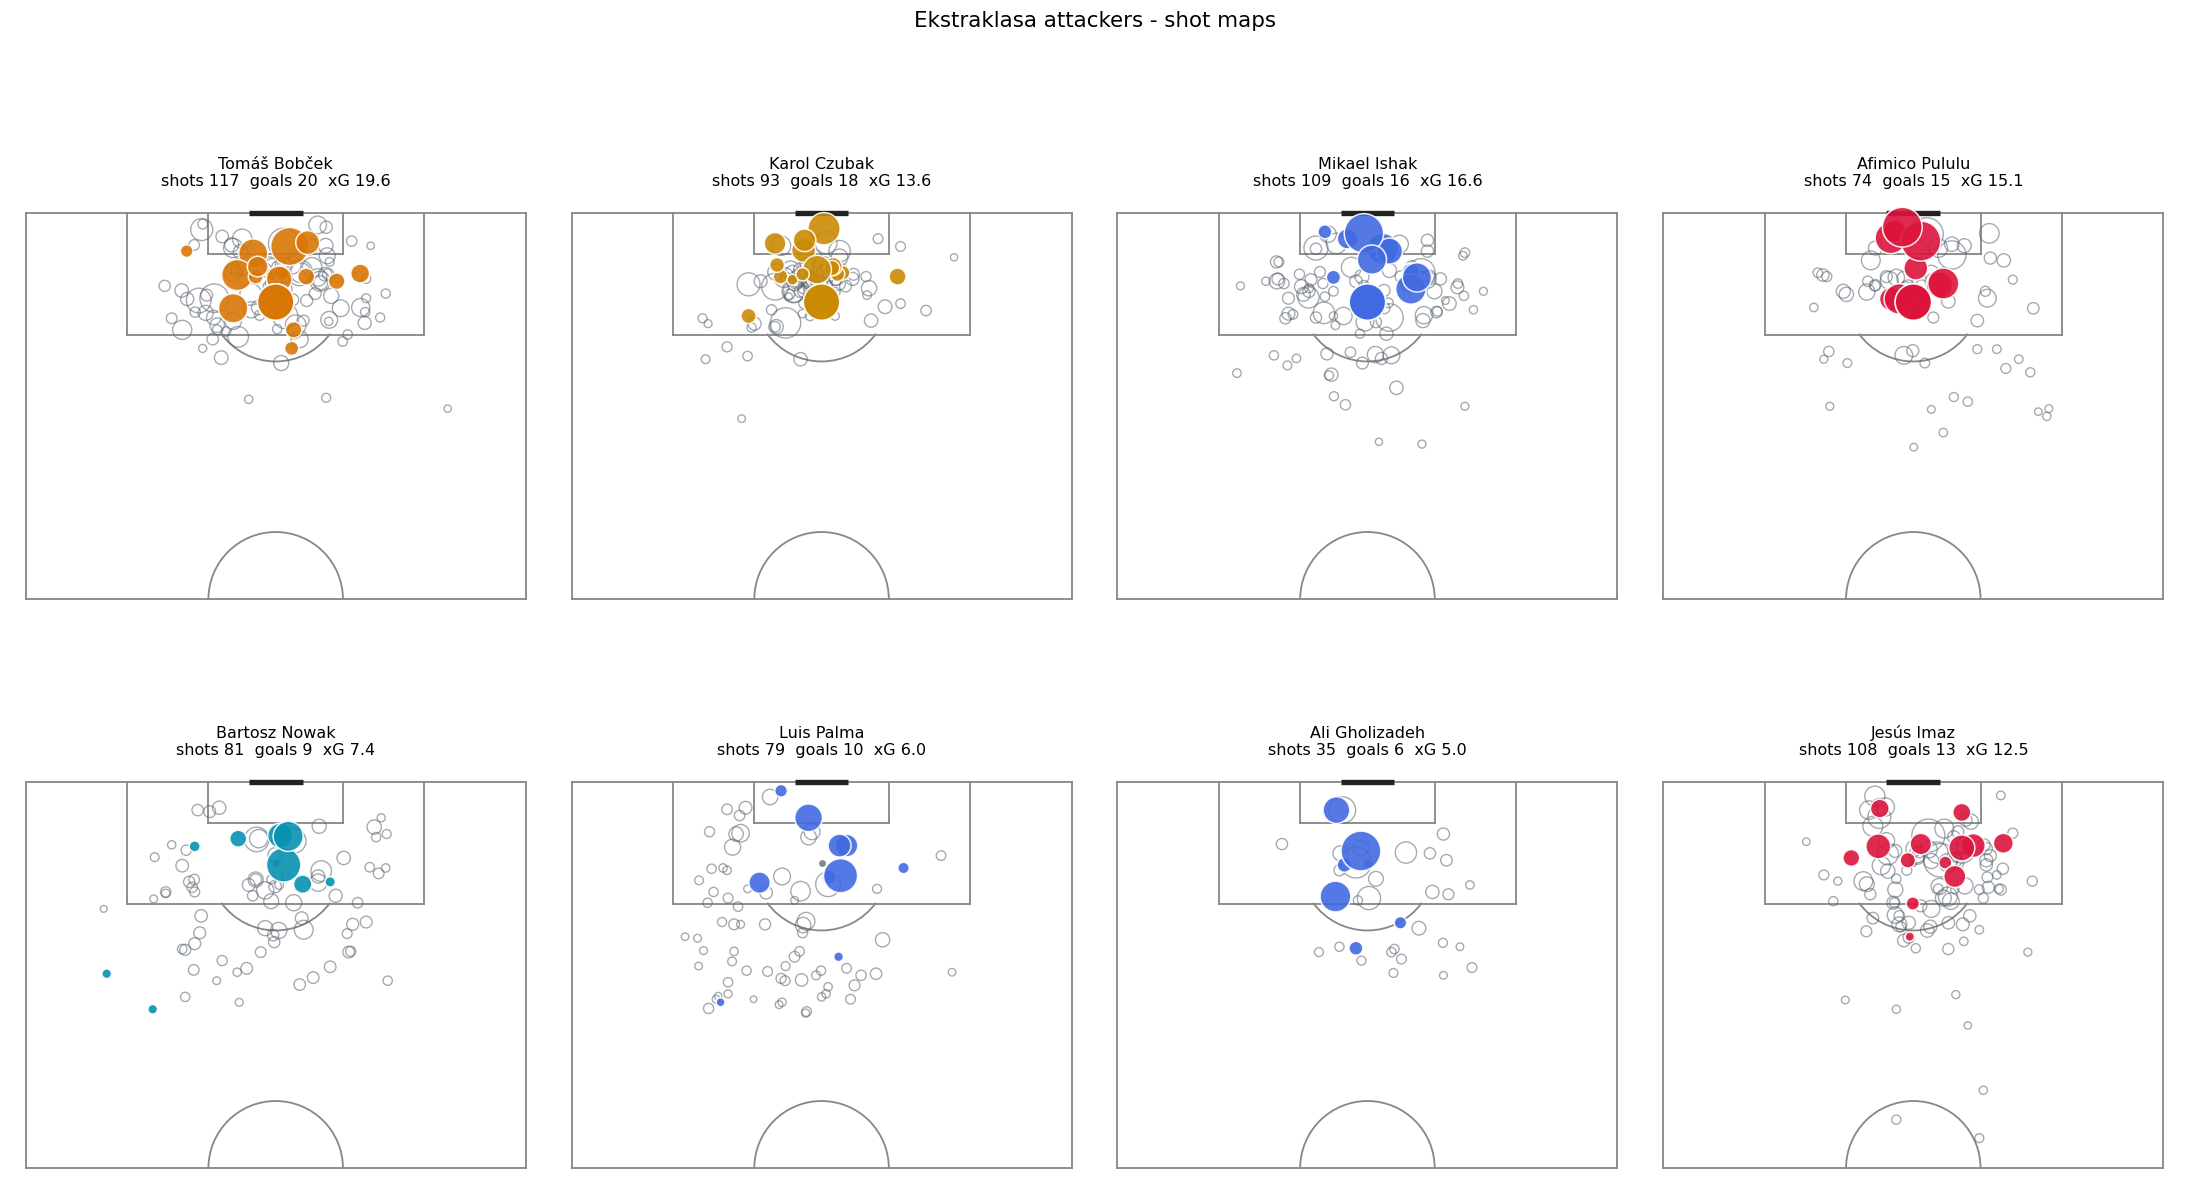

In [ ]:
def draw_vpitch(ax):
    ax.set_xlim(-2, 70)
    ax.set_ylim(-2, 55)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    line = dict(color='#888', lw=1.2)
    ax.plot([0, 68], [0, 0], **line)
    ax.plot([0, 68], [52.5, 52.5], **line)
    ax.plot([0, 0], [0, 52.5], **line)
    ax.plot([68, 68], [0, 52.5], **line)
    ax.plot([13.84, 54.16], [36, 36], **line)
    ax.plot([13.84, 13.84], [36, 52.5], **line)
    ax.plot([54.16, 54.16], [36, 52.5], **line)
    ax.plot([24.84, 43.16], [47, 47], **line)
    ax.plot([24.84, 24.84], [47, 52.5], **line)
    ax.plot([43.16, 43.16], [47, 52.5], **line)
    ax.scatter([34], [41.5], s=12, c='#888', zorder=2)
    arc = plt.matplotlib.patches.Arc((34, 41.5), 18.3, 18.3, angle=0, theta1=216, theta2=324, color='#888', lw=1.2)
    ax.add_patch(arc)
    cc = plt.matplotlib.patches.Arc((34, 0), 18.3, 18.3, angle=0, theta1=0, theta2=180, color='#888', lw=1.2)
    ax.add_patch(cc)
    ax.plot([30.34, 37.66], [52.5, 52.5], color='#222', lw=3.5, solid_capstyle='butt', zorder=3)

SHOT_PICKS = [
    ('Tomáš Bobček',    '#d97706'),
    ('Karol Czubak',    '#ca8a04'),
    ('Mikael Ishak',    LECH),
    ('Afimico Pululu',  JAGA),
    ('Bartosz Nowak',   '#0891b2'),
    ('Luis Palma',      LECH),
    ('Ali Gholizadeh',  LECH),
    ('Jesús Imaz',      JAGA),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for ax, (name, color) in zip(axes.flat, SHOT_PICKS):
    draw_vpitch(ax)
    s = shots[shots['player'] == name].copy()
    s['pitch_x'] = s['y'] * 0.68
    s['pitch_y'] = (50 - s['x']) * 1.05
    goals = s[s['is_goal']]
    misses = s[~s['is_goal']]
    ax.scatter(misses['pitch_x'], misses['pitch_y'],
               s=misses['xg'] * 700 + 15, facecolors='none', edgecolors='#5a6470',
               linewidth=0.9, alpha=0.55, zorder=4)
    ax.scatter(goals['pitch_x'], goals['pitch_y'],
               s=goals['xg'] * 700 + 15, c=color,
               edgecolor='white', linewidth=1.0, alpha=0.9, zorder=5)
    total_xg = s['xg'].sum()
    total_g = int(s['is_goal'].sum())
    ax.set_title(f'{name}\nshots {len(s)}  goals {total_g}  xG {total_xg:.1f}',
                 fontsize=10.5, pad=6)

plt.suptitle('Ekstraklasa attackers - shot maps', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIG}/06_shot_maps.png')
plt.show()

## 7. Statistical similarity

Cosine similarity on a per-90 attacking vector. Picks the closest stylistic
matches to a target player across the league. Treat it as a curiosity, not
a serious scouting tool - one season of Sofascore stats is too thin to
build hiring decisions on.

In [ ]:
TARGET = 'Afimico Pululu'

SIM_FEATURES = [
    'goals_p90', 'xg_p90', 'xa_p90', 'shots_p90',
    'key_passes_p90', 'prog_carries_p90',
    '_aerials_p90', 'recoveries_p90',
]

pool_sim = attack_pool.copy()
for f in SIM_FEATURES:
    pool_sim[f] = pool_sim[f].fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(pool_sim[SIM_FEATURES])
sim = cosine_similarity(X)

target_idx = pool_sim.index[pool_sim['name'] == TARGET][0]
target_row = pool_sim.loc[target_idx]
pool_sim['similarity'] = sim[pool_sim.index.get_loc(target_idx)]

candidates = pool_sim[
    (pool_sim['name'] != TARGET)
    & (pool_sim['team'] != target_row['team'])
    & (pool_sim['market_value_eur'] <= target_row['market_value_eur'])
].sort_values('similarity', ascending=False).head(10)

cols = ['name', 'team', 'age', 'minutes', 'market_value_eur', 'similarity',
        'goals_p90', 'xg_p90', 'xa_p90', 'key_passes_p90']
out = candidates[cols].copy()
out['minutes'] = out['minutes'].astype(int)
out['similarity'] = out['similarity'].round(3)
out['market_value_eur'] = (out['market_value_eur'] / 1000).round(0).astype(int).astype(str) + ' k'
for c in ['goals_p90', 'xg_p90', 'xa_p90', 'key_passes_p90']:
    out[c] = out[c].round(2)

print(f'Target: {TARGET}  ({target_row["team"]})')
print(f'  age {int(target_row["age"])}  minutes {int(target_row["minutes"])}  '
      f'MV {int(target_row["market_value_eur"]/1000)} k EUR')
print(f'  G/90 {target_row["goals_p90"]:.2f}  xG/90 {target_row["xg_p90"]:.2f}  '
      f'xA/90 {target_row["xa_p90"]:.2f}  KP/90 {target_row["key_passes_p90"]:.2f}')
print()
print('Top 10 similar (cheaper MV cap, different team):')
print(out.to_string(index=False))

Target: Afimico Pululu  (Jagiellonia Białystok)
  age 27  minutes 2359  MV 4300 k EUR
  G/90 0.57  xG/90 0.57  xA/90 0.14  KP/90 1.26

Top 10 similar (cheaper MV cap, different team):
                name                         team  age  minutes market_value_eur  similarity  goals_p90  xg_p90  xa_p90  key_passes_p90
        Mikael Ishak                  Lech Poznań   33     2436            775 k       0.924       0.59    0.61    0.15            1.26
              Capita               Radomiak Radom   24     1319           1900 k       0.892       0.41    0.45    0.10            1.02
       Eman Marković                 GKS Katowice   27     1146            465 k       0.861       0.63    0.35    0.13            0.94
         Ousmane Sow                Górnik Zabrze   25     1149           1500 k       0.825       0.55    0.43    0.14            1.25
Mohamed Lamine Diaby            Raków Częstochowa   25     1417           1900 k       0.814       0.44    0.49    0.10            0.89
